# 01 — Data Cleaning & Preprocessing

**Project:** Network Intrusion Detection using ML with Explainable AI  
**Program:** IEEE CS Bangalore Chapter — SIMP 2026  
**Team:** Piyush M. Borkar, Varun Gada  

---

### Notebook Objectives
1. Load the NSL-KDD training and test datasets
2. Assign correct column names
3. Inspect the data (shape, types, nulls, duplicates)
4. Drop the difficulty column
5. Encode categorical features
6. Create binary and multiclass label columns
7. Save cleaned datasets to `data/processed/`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Define Column Names

NSL-KDD has **41 network traffic features** + `label` + `difficulty_level`.  
The `.txt` files have no header row, so we assign column names manually.

In [2]:
COLUMNS = [
    # Basic features
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
    # Content features
    'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login',
    # Traffic features
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate',
    # Host-based traffic features
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    # Target
    'label',
    'difficulty_level'
]

# Categorical features (3 nominal columns)
CAT_COLS = ['protocol_type', 'service', 'flag']

print(f'Total columns defined: {len(COLUMNS)}')
print(f'Feature columns     : {len(COLUMNS) - 2}  (excluding label & difficulty)')
print(f'Categorical features: {CAT_COLS}')

Total columns defined: 43
Feature columns     : 41  (excluding label & difficulty)
Categorical features: ['protocol_type', 'service', 'flag']


## 3. Load Datasets

In [3]:
TRAIN_PATH = '../data/raw/nsl-kdd/KDDTrain+.txt'
TEST_PATH  = '../data/raw/nsl-kdd/KDDTest+.txt'

df_train = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)
df_test  = pd.read_csv(TEST_PATH,  header=None, names=COLUMNS)

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)

Train shape: (125973, 43)
Test shape : (22544, 43)


## 4. Initial Inspection

In [4]:
# First 5 rows
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
# Data types
df_train.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [6]:
# Statistical summary of numerical columns
df_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [7]:
# Check for null values
print('=== Null Values (Train) ===')
print(df_train.isnull().sum().sum(), 'total nulls')

print('\n=== Null Values (Test) ===')
print(df_test.isnull().sum().sum(), 'total nulls')

=== Null Values (Train) ===
0 total nulls

=== Null Values (Test) ===
0 total nulls


In [8]:
# Check for duplicate rows
print('Duplicates in Train:', df_train.duplicated().sum())
print('Duplicates in Test :', df_test.duplicated().sum())

Duplicates in Train: 0
Duplicates in Test : 0


## 5. Drop Duplicates & Difficulty Column

- `difficulty_level` is a meta-column specific to NSL-KDD (not a network feature)  
- It indicates how hard a record is to classify — not useful for model training

In [9]:
# Drop difficulty column
df_train.drop(columns=['difficulty_level'], inplace=True)
df_test.drop(columns=['difficulty_level'],  inplace=True)

# Drop duplicates
before = len(df_train)
df_train.drop_duplicates(inplace=True)
after = len(df_train)
print(f'Dropped {before - after} duplicate rows from train set.')

print('\nNew shapes:')
print('Train:', df_train.shape)
print('Test :', df_test.shape)

Dropped 0 duplicate rows from train set.

New shapes:
Train: (125973, 42)
Test : (22544, 42)


## 6. Explore Label Distribution

NSL-KDD has 5 main attack categories:

| Category | Description |
|----------|-------------|
| `normal` | Normal traffic |
| `DoS`    | Denial of Service |
| `Probe`  | Surveillance / Scanning |
| `R2L`    | Remote to Local |
| `U2R`    | User to Root |

In [10]:
print('=== Unique Labels in Train ===')
print(df_train['label'].unique())
print(f'\nTotal unique labels: {df_train["label"].nunique()}')

=== Unique Labels in Train ===
<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str

Total unique labels: 23


In [11]:
# Attack type to category mapping
DOS_ATTACKS   = ['back','land','neptune','pod','smurf','teardrop','apache2',
                 'udpstorm','processtable','mailbomb']
PROBE_ATTACKS = ['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L_ATTACKS   = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster',
                 'warezclient','spy','xlock','xsnoop','snmpguess','snmpgetattack',
                 'httptunnel','sendmail','named']
U2R_ATTACKS   = ['buffer_overflow','loadmodule','rootkit','perl','sqlattack',
                 'xterm','ps']

def map_to_category(label):
    if label == 'normal':       return 'Normal'
    elif label in DOS_ATTACKS:  return 'DoS'
    elif label in PROBE_ATTACKS:return 'Probe'
    elif label in R2L_ATTACKS:  return 'R2L'
    elif label in U2R_ATTACKS:  return 'U2R'
    else:                       return 'Unknown'

df_train['attack_category'] = df_train['label'].apply(map_to_category)
df_test['attack_category']  = df_test['label'].apply(map_to_category)

print('Attack category distribution (Train):')
print(df_train['attack_category'].value_counts())

Attack category distribution (Train):
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


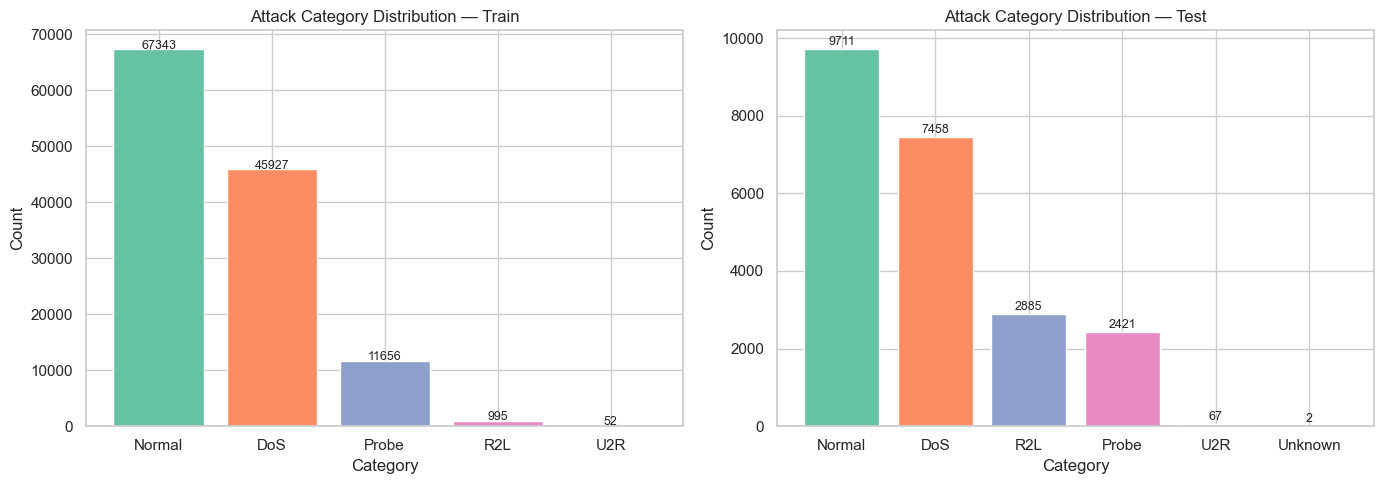

Plot saved to results/graphs/


In [12]:
# Visualize attack category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_counts = df_train['attack_category'].value_counts()
axes[0].bar(train_counts.index, train_counts.values, color=sns.color_palette('Set2', len(train_counts)))
axes[0].set_title('Attack Category Distribution — Train')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

# Test
test_counts = df_test['attack_category'].value_counts()
axes[1].bar(test_counts.index, test_counts.values, color=sns.color_palette('Set2', len(test_counts)))
axes[1].set_title('Attack Category Distribution — Test')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/graphs/attack_category_distribution.png', dpi=150)
plt.show()
print('Plot saved to results/graphs/')

## 7. Create Binary Label

For binary classification:  
- `0` → Normal  
- `1` → Attack

In [13]:
df_train['binary_label'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['binary_label']  = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

print('Binary label distribution (Train):')
print(df_train['binary_label'].value_counts())
print('\n0 = Normal | 1 = Attack')

Binary label distribution (Train):
binary_label
0    67343
1    58630
Name: count, dtype: int64

0 = Normal | 1 = Attack


## 8. Encode Categorical Features

Three categorical columns: `protocol_type`, `service`, `flag`  
We use **one-hot encoding** to avoid implying ordinal relationships.

In [14]:
print('Unique values per categorical column:')
for col in CAT_COLS:
    print(f'  {col}: {df_train[col].unique()}')

Unique values per categorical column:
  protocol_type: <StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str
  service: <StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'po

In [15]:
# One-hot encode on combined data to ensure consistent columns
combined = pd.concat([df_train, df_test], axis=0)
combined_encoded = pd.get_dummies(combined, columns=CAT_COLS, drop_first=False)

# Split back into train and test
df_train_enc = combined_encoded.iloc[:len(df_train)].copy().reset_index(drop=True)
df_test_enc  = combined_encoded.iloc[len(df_train):].copy().reset_index(drop=True)

print('Train shape after encoding:', df_train_enc.shape)
print('Test shape after encoding :', df_test_enc.shape)

Train shape after encoding: (125973, 125)
Test shape after encoding : (22544, 125)


## 9. Final Verification

In [16]:
print('=== Final Train Dataset ===')
print('Shape       :', df_train_enc.shape)
print('Null values :', df_train_enc.isnull().sum().sum())
print('Columns     :', list(df_train_enc.columns[-6:]), '... (last 6 shown)')

print('\n=== Final Test Dataset ===')
print('Shape       :', df_test_enc.shape)
print('Null values :', df_test_enc.isnull().sum().sum())

=== Final Train Dataset ===
Shape       : (125973, 125)
Null values : 0
Columns     : ['flag_S0', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'] ... (last 6 shown)

=== Final Test Dataset ===
Shape       : (22544, 125)
Null values : 0


## 10. Save Processed Data

In [17]:
os.makedirs('../data/processed', exist_ok=True)

df_train_enc.to_csv('../data/processed/train_cleaned.csv', index=False)
df_test_enc.to_csv('../data/processed/test_cleaned.csv',   index=False)

print('Saved:')
print('  data/processed/train_cleaned.csv')
print('  data/processed/test_cleaned.csv')

Saved:
  data/processed/train_cleaned.csv
  data/processed/test_cleaned.csv


---
## Summary

| Step | Action | Status |
|------|--------|--------|
| Load | Loaded KDDTrain+ and KDDTest+ | ✅ |
| Inspect | Checked nulls, duplicates, dtypes | ✅ |
| Clean | Dropped difficulty column + duplicates | ✅ |
| Labels | Created `attack_category` and `binary_label` | ✅ |
| Encode | One-hot encoded categorical features | ✅ |
| Save | Exported to `data/processed/` | ✅ |
